In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

## Load and clean the dataset

- drop `CLIENTNUM` because it is just a customer ID.
- drop the two `Naive_Bayes_Classifier...` columns because they are model-generated columns and should not be used as input features.
- Target:
  - `Existing Customer` = 0
  - `Attrited Customer` = 1

In [3]:
# Load data
df = pd.read_csv("BankChurners.csv")

# Drop ID and leakage columns
drop_cols = ["CLIENTNUM"] + [col for col in df.columns if col.startswith("Naive_Bayes_Classifier")]
df = df.drop(columns=drop_cols)

# Encode target
df["Attrition_Flag"] = df["Attrition_Flag"].map({
    "Existing Customer": 0,
    "Attrited Customer": 1
})


df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


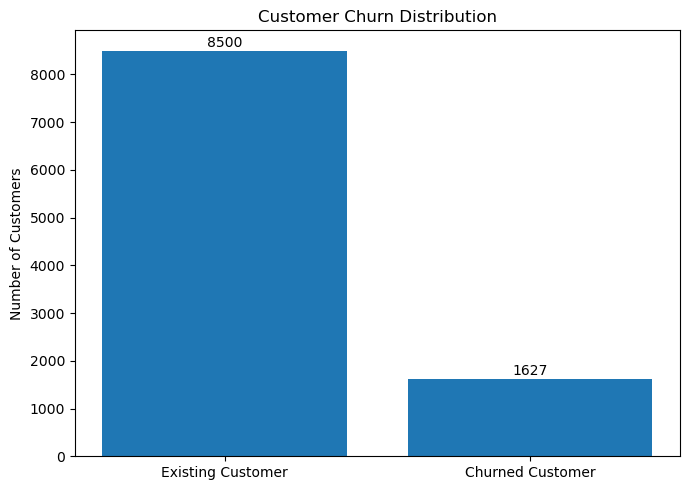

Churn rate: 16.07%


In [4]:
# churn distribution
churn_counts = df["Attrition_Flag"].value_counts().sort_index()
labels = ["Existing Customer", "Churned Customer"]

plt.figure(figsize=(7, 5))
plt.bar(labels, churn_counts.values)
plt.title("Customer Churn Distribution")
plt.ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    plt.text(i, v + 80, str(v), ha="center")
plt.tight_layout()
plt.show()

churn_rate = df["Attrition_Flag"].mean() * 100
print(f"Churn rate: {churn_rate:.2f}%")

## Dataset overview

###  visuals:
1. **Customer Age distribution by churn status**
2. **Churn rate by Card Category**


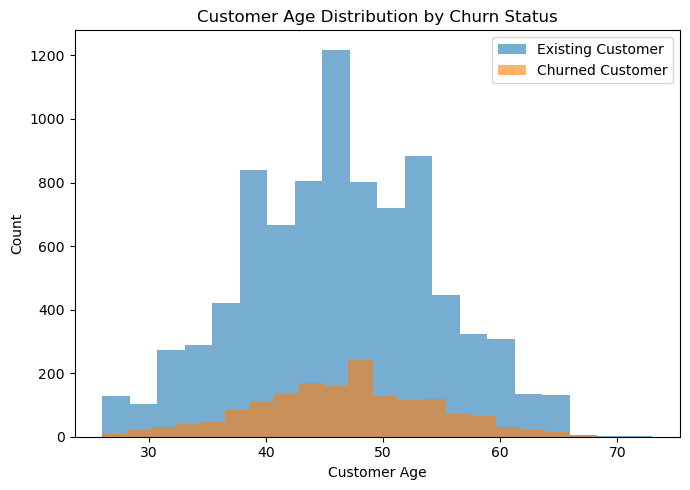

In [6]:
# Dataset overview plot 1: Customer Age by churn status
plt.figure(figsize=(7, 5))
for target_value, label in [(0, "Existing Customer"), (1, "Churned Customer")]:
    plt.hist(
        df.loc[df["Attrition_Flag"] == target_value, "Customer_Age"],
        bins=20,
        alpha=0.6,
        label=label
    )
plt.title("Customer Age Distribution by Churn Status")
plt.xlabel("Customer Age")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

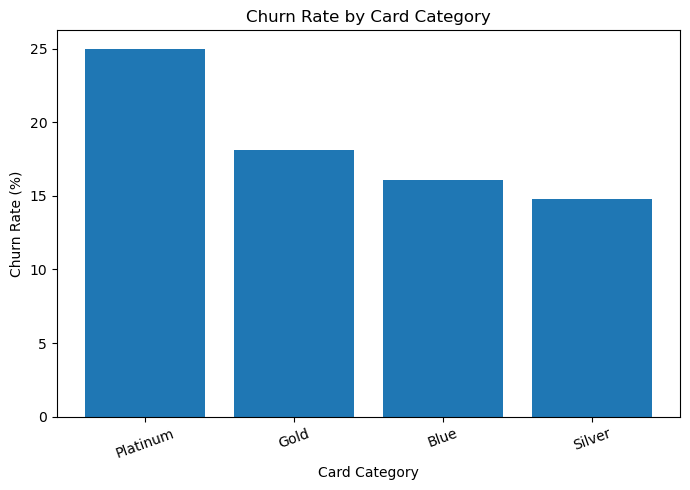

,Churn Rate (%)
Card_Category,
Platinum,25.000000
Gold,18.103448
Blue,16.097923
Silver,14.774775


In [7]:
# Dataset overview plot 2: Churn rate by card category
card_churn = (
    df.groupby("Card_Category")["Attrition_Flag"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(7, 5))
plt.bar(card_churn.index, card_churn.values)
plt.title("Churn Rate by Card Category")
plt.xlabel("Card Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

card_churn.to_frame(name="Churn Rate (%)")

In [8]:
# Separate features and target
X = df.drop(columns=["Attrition_Flag"])
y = df["Attrition_Flag"]

# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True)

print("Modeling feature matrix shape:", X.shape)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Modeling feature matrix shape: (10127, 32)


## Logistic Regression

###  visuals
1. Confusion Matrix
2. Top 10 absolute coefficient magnitudes
3.  ROC curve


In [10]:
# Logistic Regression model
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# Metrics
log_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1 Score": f1_score(y_test, y_pred_log)
}

pd.DataFrame(log_metrics, index=["Logistic Regression"]).T

,Logistic Regression
Accuracy,0.854886
Precision,0.530938
Recall,0.818462
F1 Score,0.644068


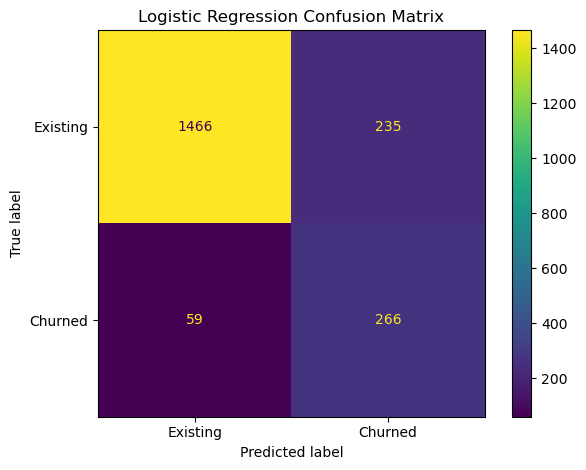

In [11]:
# Logistic plot 1: confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["Existing", "Churned"])
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

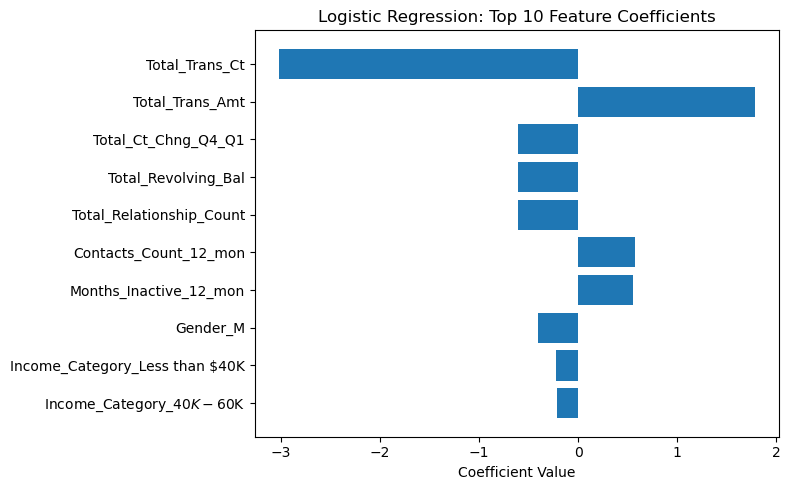

,Feature,Coefficient
11,Total_Trans_Ct,-3.024478
10,Total_Trans_Amt,1.790733
12,Total_Ct_Chng_Q4_Q1,-0.606237
7,Total_Revolving_Bal,-0.604718
3,Total_Relationship_Count,-0.601669
5,Contacts_Count_12_mon,0.579679
4,Months_Inactive_12_mon,0.557786
14,Gender_M,-0.402141
27,Income_Category_Less than $40K,-0.226488
24,Income_Category_$40K - $60K,-0.214332


In [12]:
# Logistic plot 2: top 10 coefficient magnitudes
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
top10_coef = coef_df.sort_values("Abs_Coefficient", ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10_coef["Feature"][::-1], top10_coef["Coefficient"][::-1])
plt.title("Logistic Regression: Top 10 Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

top10_coef[["Feature", "Coefficient"]]

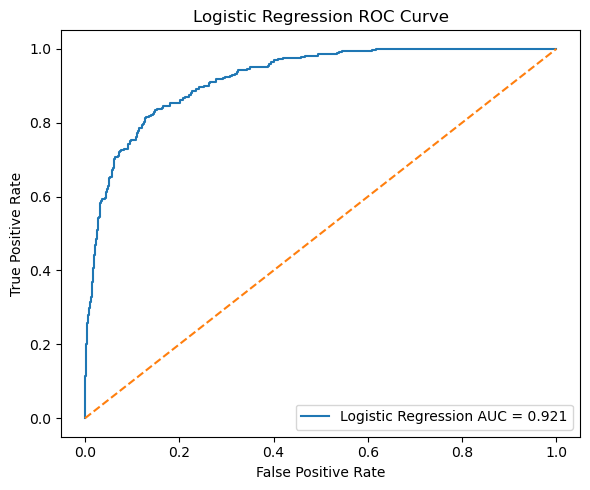

In [13]:
# Logistic plot 3: ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = auc(fpr_log, tpr_log)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression AUC = {auc_log:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()